In [70]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [71]:
# import pandas as pd
# import xarray as xr
# import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import glob
from src.utils import *
from openberg_july2026.src2.utils0 import *
from openberg_july2026.src2.utils2 import *
from openberg_july2026.src2.utils3 import *

In [72]:
%matplotlib inline

In [94]:
ib = 'iceberg2025w'
#read sim
file_contain_all = [ib,'idx','topaz6']
file_contain_any = ['_']
file_notcontain = ['test','prof',]#'test','wa','next','glorys']#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = file_l[::-1]
file_dict_idx(file_l)

{'iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix.nc': {'files': ['./results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx0-0_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx1-1_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx2-2_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx3-3_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx4-4_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx5-5_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx6-6_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx7-7_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx8-8_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx9-9_newcoefmix.nc',
   './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx10-10_newcoefmix.nc',
 

In [95]:
#file_l for idx
fname = 'iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix.nc'
file_l = file_dict_idx(file_l)[fname]['files']
idx_l = file_dict_idx(file_l)[fname]['idx']
print(fname,idx_l,file_l)

iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix.nc [[0, 0], [1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10], [11, 11], [12, 12]] ['./results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx0-0_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx1-1_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx2-2_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx3-3_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx4-4_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx5-5_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx6-6_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx7-7_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx8-8_newcoefmix.nc', './results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_idx9-9_newcoefmix.nc', './results/iceber

In [96]:
# Join individual idx files
join_ds_by_idx(file_dict_idx(file_l)[fname]['files'])

# # #if overlap in trajectories: subset, save, rejoin
# # test = xr.open_dataset()
# # test = test.sel(trajectory:np.arange())
# # test.to_netcdf('.nc','w')

# # #test
# test = xr.open_dataset('./results/'+fname.replace('.nc','_joined.nc'))
# print(np.all(np.isnan(test.lat.values)), test.trajectory.values)
# test.x_sea_water_velocity.plot()
# test

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026/src2/utils2.py:198: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(


./results/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix_joined.nc


## Correct time in datasets


In [133]:
#load files
datasets = [xr.open_dataset(f) for f in file_l]

In [134]:
#check dims
print([sim.dims for sim in datasets])
[list(sim.time.values[np.array([0,-1])]) for sim in datasets]

[FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 96})]


[[np.datetime64('2024-07-09T09:06:18.000000000'),
  np.datetime64('2024-07-13T08:06:18.000000000')],
 [np.datetime64('2024-07-11T14:19:51.000000000'),
  np.datetime64('2024-07-15T13:19:51.000000000')],
 [np.datetime64('2024-07-18T20:13:13.000000000'),
  np.datetime64('2024-07-22T19:13:13.000000000')],
 [np.datetime64('2024-07-23T09:05:10.000000000'),
  np.datetime64('2024-07-27T08:05:10.000000000')],
 [np.datetime64('2024-07-30T20:12:13.000000000'),
  np.datetime64('2024-08-03T19:12:13.000000000')],
 [np.datetime64('2024-08-14T09:21:59.000000000'),
  np.datetime64('2024-08-18T08:21:59.000000000')],
 [np.datetime64('2024-08-15T14:17:39.000000000'),
  np.datetime64('2024-08-19T13:17:39.000000000')],
 [np.datetime64('2024-08-16T09:24:23.000000000'),
  np.datetime64('2024-08-20T08:24:23.000000000')],
 [np.datetime64('2024-08-18T20:39:58.000000000'),
  np.datetime64('2024-08-22T19:39:58.000000000')]]

In [102]:
def clean_time(ds):
    ds = ds.copy()

    # remove seconds 
    ds = ds.assign_coords(
        time=ds.time.values.astype("datetime64[h]")
    )

    # remove any duplicate times created by the rounding
    _, idx = np.unique(ds.time.values, return_index=True)
    ds = ds.isel(time=np.sort(idx))

    # print(ds.time)

    return ds

datasets = [clean_time(sim) for sim in datasets]

In [44]:
# # common time - !NOT FOR file with diff time period
# common_time = datasets[0].time

# datasets = [
#     ds.reindex(time=common_time)
#     for ds in datasets
# ]

In [45]:
#save with cleaned time
# dataset[0].to_netcdf('./results/bla.nc')

## Combine and save ds


In [135]:
# #combine along new dim run
# ds_combined = xr.concat(
#     datasets,
#     dim=xr.DataArray(
#         [f.split('/')[-1][:-3] for f in file_l],
#         dims="run",
#         name="run"
#     )
# )

/tmp/ipykernel_42506/2581972462.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(


In [141]:
#combine along existing dimensions
ds_combined = xr.concat(
    datasets,
    dim="trajectory"
)

/tmp/ipykernel_42506/574441029.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(


In [106]:
#combine along dim time
n=11 #mainrun:1, n20:20
    #fix trajectory

datasets2 = [ds.assign_coords(trajectory=idxi[0]*n+ds.trajectory.values) for ds,idxi in zip(datasets,idx_l)]
    
ds_combined = xr.concat(
    datasets2,
    dim='time'
)

/tmp/ipykernel_42506/1558812852.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'trajectory' ('trajectory',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(


In [114]:
ds_combined = ds_combined.sortby('time')

In [142]:
#check for time sorting and doubles
ds_combined.time.to_index().is_monotonic_increasing,np.where(np.diff(ds_combined.time.values) <= np.timedelta64(0, 'ns'))[0]

(True, array([], dtype=int64))

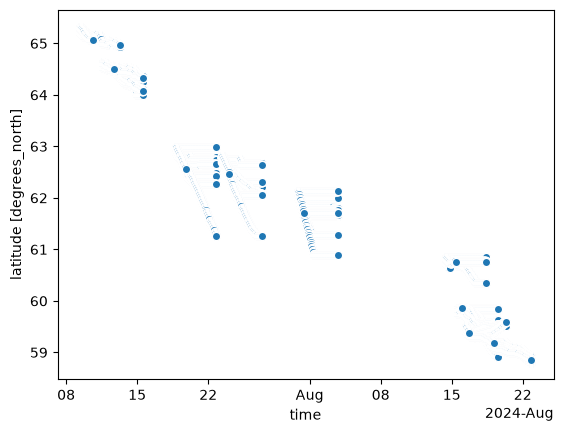

In [143]:
ds_combined.lat.plot.scatter(x='time',y='trajectory')
plt.show()

In [144]:
# ds_combined.lat.plot.scatter(x="time",y="trajectory")
ds_combined

<xarray.Dataset> Size: 14MB
Dimensions:                                   (trajectory: 99, time: 864)
Coordinates:
  * trajectory                                (trajectory) int32 396B 0 1 ... 10
  * time                                      (time) datetime64[ns] 7kB 2024-...
Data variables: (12/39)
    status                                    (trajectory, time) float64 684kB ...
    moving                                    (trajectory, time) float64 684kB ...
    age_seconds                               (trajectory, time) float32 342kB ...
    origin_marker                             (trajectory, time) float64 684kB ...
    lon                                       (trajectory, time) float32 342kB ...
    lat                                       (trajectory, time) float32 342kB ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 342kB ...
    sea_ice_area_fraction                     (trajectory, time) float32 342kB ...
    sea_ice_thickness                         (trajectory, time) float32 342kB ...
    sea_ice_x_velocity                        (trajectory, time) float32 342kB ...
    sea_ice_y_velocity                        (trajectory, time) float32 342kB ...
    land_binary_mask                          (trajectory, time) float32 342kB ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

In [87]:
outname = '_'.join(fname.split('_')[1:]).split('.')[0]
ds_combined.to_netcdf('./results/%s_%s_joined.nc'%(ib,outname))